# OULAD Predictive Analysis —  
**Hypothesis:** Positive Learning Experiences Contribute to Sustained Academic Success  
**Primary Model:** Logistic Regression (Binary outcome: Pass/Distinction vs Fail/Withdrawn)  
**Secondary Models:** OLS Regression, Time Series (ARIMA + Holt-Winters)  

## Cell 0 — Imports & Configuration

In [1]:
# ── Standard library ────────────────────────────────────────────────────────
import warnings
import os

# ── Data handling ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Statistical modelling ────────────────────────────────────────────────────
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.tsa.holtwinters as ets
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# ── Scipy ────────────────────────────────────────────────────────────────────
from scipy import stats

# ── Settings ─────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Output directories
os.makedirs('../../outputs/figures', exist_ok=True)
os.makedirs('../../outputs/tables', exist_ok=True)
os.makedirs('../../outputs/models', exist_ok=True)

print('All imports successful ✓')

All imports successful ✓


---
## T3.1 — Data Loading & Train/Test Split

We first try to load `df_features.csv` from Member 1's output.  
If it is unavailable, the fallback builds the required features directly from raw CSVs.

In [6]:
FEATURES_PATH = r'C:\Users\DELL\Desktop\TPSM-POS-LEARN\oulad-analysis\data\features\df_features.csv'
RAW_PATH      = r'C:\Users\DELL\Desktop\TPSM-POS-LEARN\oulad-analysis\data\raw\archive-5' + '\\'

# ── Primary path: use Member 1's engineered features ─────────────────────────
if os.path.exists(FEATURES_PATH):
    df = pd.read_csv(FEATURES_PATH)
    print(f'Loaded df_features.csv — shape: {df.shape}')

# ── Fallback: build features from raw CSVs ───────────────────────────────────
else:
    print('df_features.csv not found. Building from raw CSVs...')

    student_info   = pd.read_csv(RAW_PATH + 'studentInfo.csv')
    student_vle    = pd.read_csv(RAW_PATH + 'studentVle.csv')
    vle            = pd.read_csv(RAW_PATH + 'vle.csv')
    student_assess = pd.read_csv(RAW_PATH + 'studentAssessment.csv')
    assessments    = pd.read_csv(RAW_PATH + 'assessments.csv')
    courses        = pd.read_csv(RAW_PATH + 'courses.csv')
    registration   = pd.read_csv(RAW_PATH + 'studentRegistration.csv')

    # ── Total clicks per student per module ───────────────────────────────────
    click_agg = (
        student_vle
        .groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
        .sum()
        .reset_index()
        .rename(columns={'sum_click': 'total_clicks'})
    )

    # ── Early clicks: first 25% of module ────────────────────────────────────
    merged_vle = student_vle.merge(courses, on=['code_module', 'code_presentation'])
    early_mask = merged_vle['date'] < (merged_vle['module_presentation_length'] * 0.25)
    early_clicks = (
        merged_vle[early_mask]
        .groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
        .sum()
        .reset_index()
        .rename(columns={'sum_click': 'early_clicks'})
    )

    # ── Forum clicks ──────────────────────────────────────────────────────────
    forum_vle = student_vle.merge(vle[['id_site', 'activity_type']], on='id_site')
    forum_clicks = (
        forum_vle[forum_vle['activity_type'] == 'forumng']
        .groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
        .sum()
        .reset_index()
        .rename(columns={'sum_click': 'forum_clicks'})
    )

    # ── Average TMA score ─────────────────────────────────────────────────────
    tma_ids = assessments[assessments['assessment_type'] == 'TMA']['id_assessment']
    avg_tma = (
        student_assess[student_assess['id_assessment'].isin(tma_ids)]
        .groupby('id_student')['score']
        .mean()
        .reset_index()
        .rename(columns={'score': 'avg_score_TMA'})
    )

    # ── Submission delay ──────────────────────────────────────────────────────
    assess_merged = student_assess.merge(
        assessments[['id_assessment', 'date']], on='id_assessment'
    )
    assess_merged['delay'] = assess_merged['date_submitted'] - assess_merged['date']
    sub_delay = (
        assess_merged.groupby('id_student')['delay']
        .mean()
        .reset_index()
        .rename(columns={'delay': 'submission_delay'})
    )

    # ── Merge all features onto studentInfo ───────────────────────────────────
    df = student_info.copy()
    for feat_df, keys in [
        (click_agg,   ['id_student', 'code_module', 'code_presentation']),
        (early_clicks,['id_student', 'code_module', 'code_presentation']),
        (forum_clicks,['id_student', 'code_module', 'code_presentation']),
        (avg_tma,     ['id_student']),
        (sub_delay,   ['id_student']),
    ]:
        df = df.merge(feat_df, on=keys, how='left')

    # ── Binary success flag ───────────────────────────────────────────────────
    df['success_binary'] = df['final_result'].isin(['Pass', 'Distinction']).astype(int)

    # ── Composite PLE score (z-score standardise, then average) ──────────────
    ple_cols = ['total_clicks', 'early_clicks', 'forum_clicks', 'avg_score_TMA']
    df[ple_cols] = df[ple_cols].fillna(df[ple_cols].median())
    df[[c + '_z' for c in ple_cols]] = df[ple_cols].apply(stats.zscore)
    df['positive_exp_score'] = df[[c + '_z' for c in ple_cols]].mean(axis=1)

    print(f'Fallback feature engineering complete — shape: {df.shape}')

df.info()

df_features.csv not found. Building from raw CSVs...
Fallback feature engineering complete — shape: (32593, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   imd_band              31482 non-null  object 
 7   age_band              32593 non-null  object 
 8   num_of_prev_attempts  32593 non-null  int64  
 9   studied_credits       32593 non-null  int64  
 10  disability            32593 non-null  object 
 11  final_result          32593 non-null  object 
 12  total_clicks          32593 non-null  float64
 13  early_cli

In [7]:
# ── Feature list for modelling ────────────────────────────────────────────────
FEATURES = [
    'total_clicks',
    'avg_score_TMA',
    'early_clicks',
    'forum_clicks',
    'submission_delay',
    'num_of_prev_attempts',
    'studied_credits',
]
TARGET = 'success_binary'

# Drop rows missing the target or any feature
df_model = df[FEATURES + [TARGET, 'code_module']].dropna()
print(f'Modelling dataset shape after dropping NAs: {df_model.shape}')
print(f'Class balance:\n{df_model[TARGET].value_counts(normalize=True).round(3)}')

Modelling dataset shape after dropping NAs: (26746, 9)
Class balance:
success_binary
1    0.575
0    0.425
Name: proportion, dtype: float64


In [8]:
# ── Stratified 80/20 train-test split ────────────────────────────────────────
# Stratify on both success_binary AND code_module to preserve module distribution
stratify_col = df_model[TARGET].astype(str) + '_' + df_model['code_module']

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=stratify_col
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Train class balance: {y_train.mean():.3f} positive')
print(f'Test  class balance: {y_test.mean():.3f} positive')

Training set : 21,396 rows
Test set     : 5,350 rows
Train class balance: 0.575 positive
Test  class balance: 0.575 positive


---
## T3.2 — OLS Regression: Predicting `avg_score_TMA`

Before logistic regression, we run OLS to understand which engagement features
predict **continuous assessment performance**. This directly feeds into our evidence
that engagement drives outcomes.

In [9]:
# ── OLS setup: predict avg_score_TMA from engagement variables ────────────────
ols_features = ['total_clicks', 'early_clicks', 'forum_clicks', 'submission_delay']

df_ols = df[ols_features + ['avg_score_TMA']].dropna()
X_ols = sm.add_constant(df_ols[ols_features])
y_ols = df_ols['avg_score_TMA']

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          avg_score_TMA   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     688.4
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:41:15   Log-Likelihood:            -1.0924e+05
No. Observations:               26746   AIC:                         2.185e+05
Df Residuals:                   26741   BIC:                         2.185e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               67.4406      0.119  

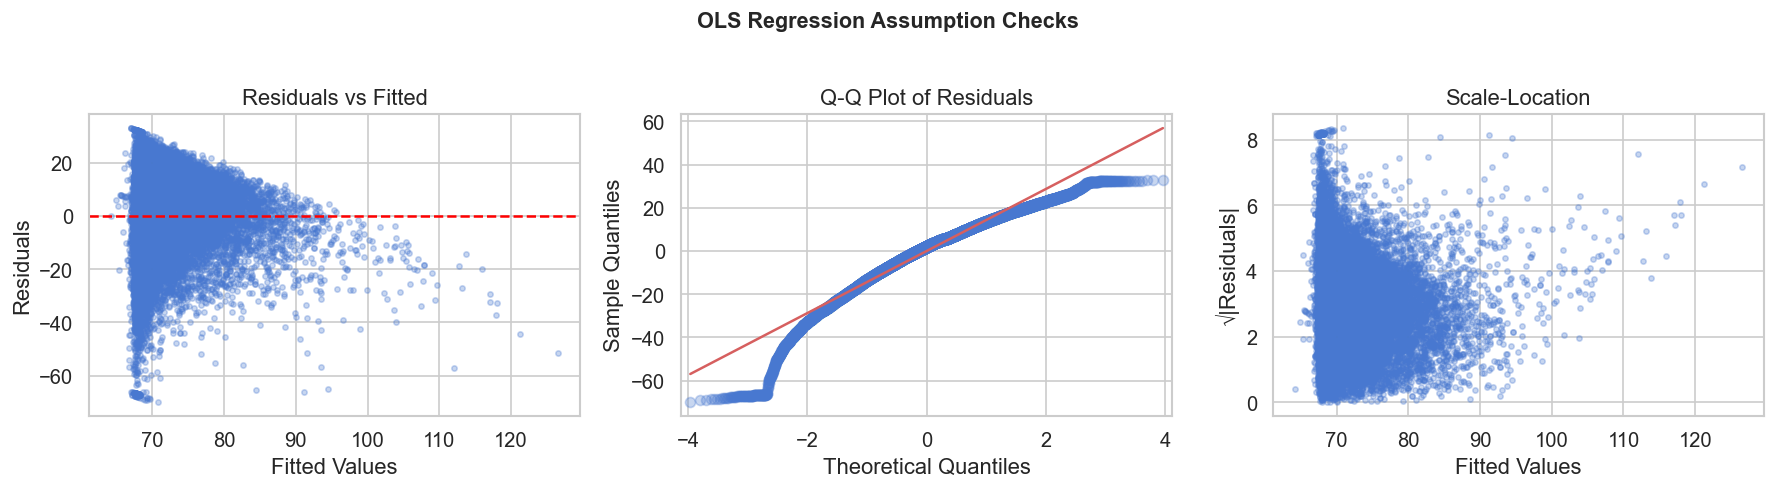

Breusch-Pagan test  →  LM statistic: 241.504,  p-value: 0.0000
  Interpretation: p < 0.05 indicates heteroscedasticity (non-constant variance).
Durbin-Watson statistic: 1.883  (ideal ≈ 2.0; <1.5 or >2.5 indicates autocorrelation)


In [10]:
# ── OLS assumption checks ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Residuals vs Fitted
axes[0].scatter(ols_model.fittedvalues, ols_model.resid, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# 2. Q-Q plot (normality of residuals)
sm.qqplot(ols_model.resid, line='s', ax=axes[1], alpha=0.3)
axes[1].set_title('Q-Q Plot of Residuals')

# 3. Scale-Location (homoscedasticity)
axes[2].scatter(ols_model.fittedvalues, np.sqrt(np.abs(ols_model.resid)), alpha=0.3, s=10)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('√|Residuals|')
axes[2].set_title('Scale-Location')

plt.suptitle('OLS Regression Assumption Checks', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/figures/ols_assumptions.png', bbox_inches='tight')
plt.show()

# Breusch-Pagan heteroscedasticity test
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(ols_model.resid, X_ols)
print(f'Breusch-Pagan test  →  LM statistic: {bp_lm:.3f},  p-value: {bp_p:.4f}')
print('  Interpretation: p < 0.05 indicates heteroscedasticity (non-constant variance).')

# Durbin-Watson autocorrelation test
dw = durbin_watson(ols_model.resid)
print(f'Durbin-Watson statistic: {dw:.3f}  (ideal ≈ 2.0; <1.5 or >2.5 indicates autocorrelation)')

In [11]:
# ── VIF: multicollinearity check ──────────────────────────────────────────────
vif_data = pd.DataFrame()
vif_data['Feature'] = X_ols.columns
vif_data['VIF'] = [variance_inflation_factor(X_ols.values, i)
                   for i in range(X_ols.shape[1])]
vif_data = vif_data[vif_data['Feature'] != 'const']
print('Variance Inflation Factors (VIF < 5 is acceptable):')
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

Variance Inflation Factors (VIF < 5 is acceptable):
         Feature      VIF
    early_clicks 5.416657
    total_clicks 5.345663
    forum_clicks 2.136825
submission_delay 1.217127


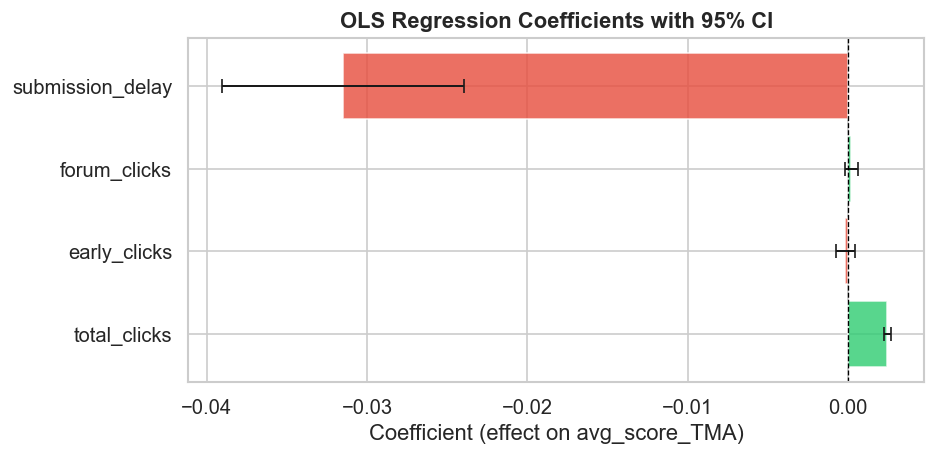


Model R² = 0.0934  |  Adjusted R² = 0.0932
F-statistic p-value = 0.0000e+00


In [12]:
# ── OLS coefficient plot ──────────────────────────────────────────────────────
coef = ols_model.params.drop('const')
conf = ols_model.conf_int().drop('const')
err_lower = coef - conf[0]
err_upper = conf[1] - coef

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef]
ax.barh(coef.index, coef.values, color=colors, alpha=0.8,
        xerr=[err_lower, err_upper], capsize=4, error_kw={'linewidth': 1.2})
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (effect on avg_score_TMA)')
ax.set_title('OLS Regression Coefficients with 95% CI', fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/ols_coefficients.png', bbox_inches='tight')
plt.show()

print(f"\nModel R² = {ols_model.rsquared:.4f}  |  Adjusted R² = {ols_model.rsquared_adj:.4f}")
print(f"F-statistic p-value = {ols_model.f_pvalue:.4e}")

---
## T3.3 — Logistic Regression: Predicting `success_binary` (Primary Model)

Logistic regression models the **probability** of sustained academic success.  
We use `statsmodels` for full statistical output (p-values, odds ratios) and
`scikit-learn` for AUC-ROC and cross-validation.

In [13]:
# ── Statsmodels Logit (for statistical inference) ────────────────────────────
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_sm).fit(maxiter=200)
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.429542
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         success_binary   No. Observations:                21396
Model:                          Logit   Df Residuals:                    21388
Method:                           MLE   Df Model:                            7
Date:                Sat, 04 Apr 2026   Pseudo R-squ.:                  0.3700
Time:                        08:41:38   Log-Likelihood:                -9190.5
converged:                       True   LL-Null:                       -14588.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -3.3400      0.106    -31.451      0.000      -3.548      -3.132

In [14]:
# ── Odds Ratios with 95% CI ───────────────────────────────────────────────────
odds_ratios = np.exp(logit_model.params)
odds_ci     = np.exp(logit_model.conf_int())
or_df = pd.concat([odds_ratios, odds_ci], axis=1)
or_df.columns = ['Odds_Ratio', 'CI_2.5%', 'CI_97.5%']
or_df = or_df.drop('const').round(4)
or_df['Significant (p<0.05)'] = logit_model.pvalues.drop('const') < 0.05
print('Odds Ratios (OR > 1 = increases probability of success):')
print(or_df.to_string())

or_df.to_csv('../../outputs/tables/logistic_odds_ratios.csv')

Odds Ratios (OR > 1 = increases probability of success):
                      Odds_Ratio  CI_2.5%  CI_97.5%  Significant (p<0.05)
total_clicks              1.0032   1.0031    1.0033                  True
avg_score_TMA             1.0472   1.0443    1.0502                  True
early_clicks              0.9943   0.9941    0.9946                  True
forum_clicks              1.0014   1.0012    1.0016                  True
submission_delay          1.0076   1.0057    1.0094                  True
num_of_prev_attempts      0.6945   0.6409    0.7525                  True
studied_credits           0.9948   0.9939    0.9957                  True


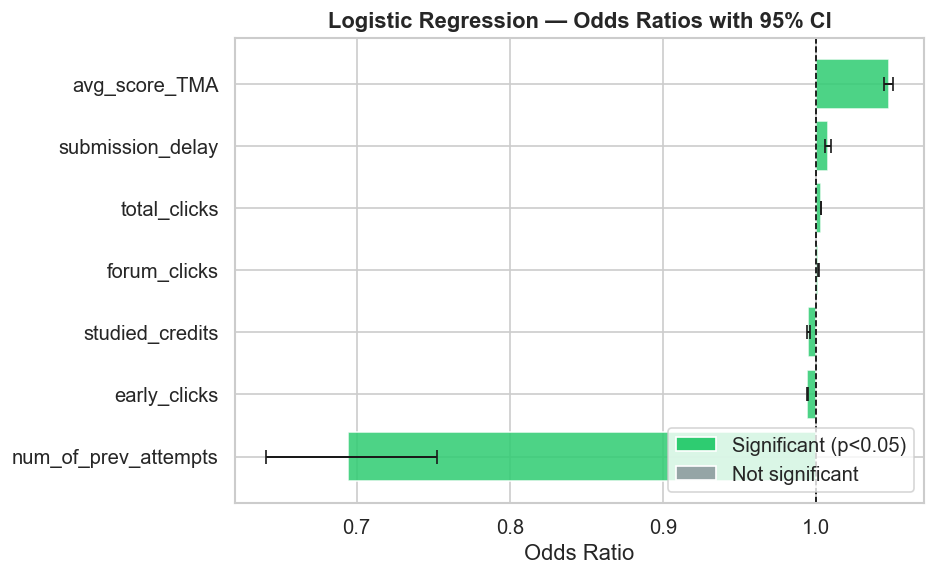

In [15]:
# ── Odds Ratio Forest Plot ────────────────────────────────────────────────────
or_plot = or_df.copy().sort_values('Odds_Ratio')
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71' if sig else '#95a5a6' for sig in or_plot['Significant (p<0.05)']]
ax.barh(or_plot.index, or_plot['Odds_Ratio'] - 1, left=1, color=colors, alpha=0.85,
        xerr=[or_plot['Odds_Ratio'] - or_plot['CI_2.5%'],
              or_plot['CI_97.5%'] - or_plot['Odds_Ratio']],
        capsize=4, error_kw={'linewidth': 1.2})
ax.axvline(1, color='black', linewidth=1, linestyle='--', label='No effect (OR=1)')
ax.set_xlabel('Odds Ratio')
ax.set_title('Logistic Regression — Odds Ratios with 95% CI', fontweight='bold')
ax.legend()

# Colour legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#2ecc71', label='Significant (p<0.05)'),
                Patch(facecolor='#95a5a6', label='Not significant')]
ax.legend(handles=legend_elems, loc='lower right')
plt.tight_layout()
plt.savefig('../../outputs/figures/logistic_odds_ratios.png', bbox_inches='tight')
plt.show()

In [16]:
# ── Marginal Effects ──────────────────────────────────────────────────────────
marginal_effects = logit_model.get_margeff()
print(marginal_effects.summary())
print('\nMarginal effects show the change in PROBABILITY of success per 1-unit increase in each predictor.')

        Logit Marginal Effects       
Dep. Variable:         success_binary
Method:                          dydx
At:                           overall
                          dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
total_clicks             0.0005   5.52e-06     82.959      0.000       0.000       0.000
avg_score_TMA            0.0066      0.000     36.399      0.000       0.006       0.007
early_clicks            -0.0008   1.25e-05    -64.626      0.000      -0.001      -0.001
forum_clicks             0.0002    1.5e-05     13.138      0.000       0.000       0.000
submission_delay         0.0011      0.000      8.111      0.000       0.001       0.001
num_of_prev_attempts    -0.0518      0.006     -8.973      0.000      -0.063      -0.040
studied_credits         -0.0007   6.82e-05    -10.864      0.000      -0.001      -0.001

Marginal effects show the change in PROBABILIT

---
## T3.4 — Model Diagnostics & Performance Evaluation

In [17]:
# ── Predictions on test set ───────────────────────────────────────────────────
y_prob_sm = logit_model.predict(X_test_sm)   # predicted probabilities
y_pred_sm = (y_prob_sm >= 0.5).astype(int)   # binary predictions at threshold 0.5

# ── Core metrics ─────────────────────────────────────────────────────────────
acc   = accuracy_score(y_test, y_pred_sm)
auc   = roc_auc_score(y_test, y_prob_sm)

print(f'Accuracy : {acc:.4f}')
print(f'AUC-ROC  : {auc:.4f}  (acceptable if > 0.70)\n')
print('Classification Report:')
print(classification_report(y_test, y_pred_sm, target_names=['Fail/Withdrawn', 'Pass/Distinction']))

Accuracy : 0.8275
AUC-ROC  : 0.9050  (acceptable if > 0.70)

Classification Report:
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.78      0.83      0.80      2272
Pass/Distinction       0.87      0.83      0.85      3078

        accuracy                           0.83      5350
       macro avg       0.82      0.83      0.82      5350
    weighted avg       0.83      0.83      0.83      5350



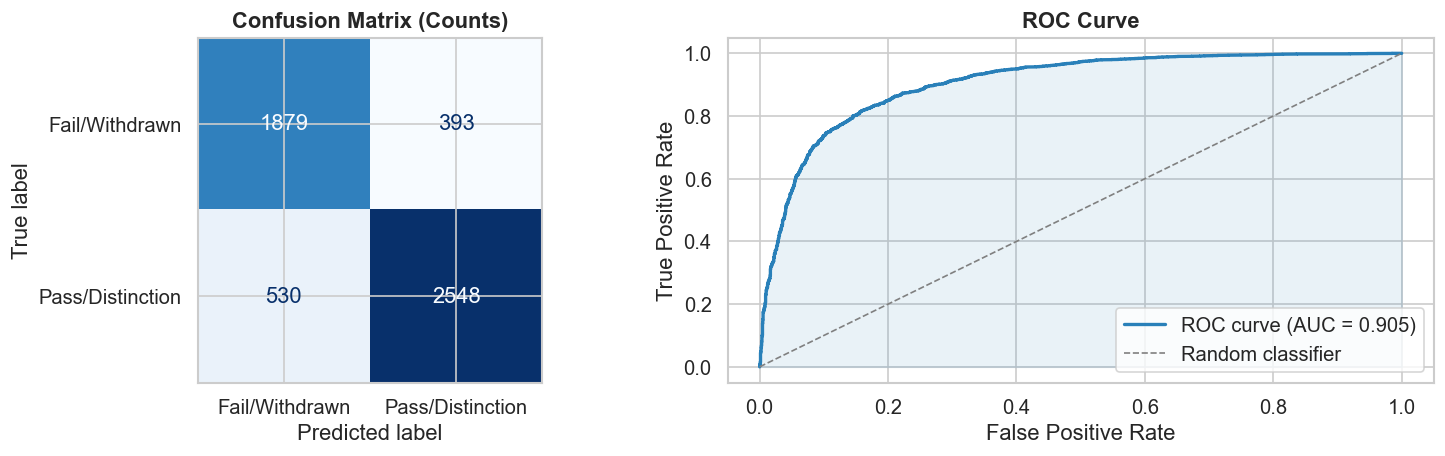

In [18]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix (counts)
cm = confusion_matrix(y_test, y_pred_sm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Fail/Withdrawn', 'Pass/Distinction'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_sm)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../../outputs/figures/logistic_performance.png', bbox_inches='tight')
plt.show()

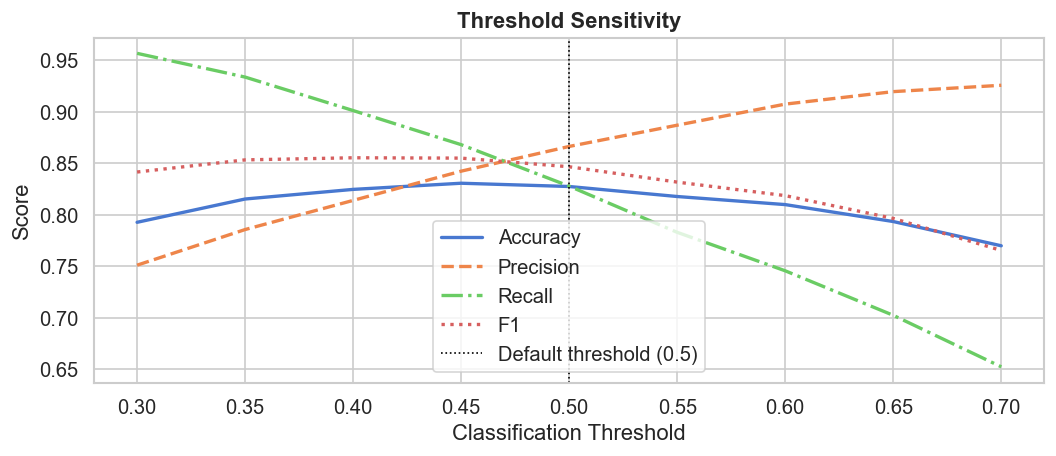

 threshold  accuracy  precision   recall       f1
      0.30  0.792710   0.751084 0.956790 0.841549
      0.35  0.815327   0.785675 0.933723 0.853325
      0.40  0.824673   0.813967 0.901235 0.855381
      0.45  0.830654   0.842371 0.868096 0.855040
      0.50  0.827477   0.866372 0.827810 0.846652
      0.55  0.817757   0.887008 0.782976 0.831752
      0.60  0.809907   0.907473 0.745614 0.818620
      0.65  0.793458   0.919609 0.702404 0.796463
      0.70  0.769907   0.925772 0.652372 0.765390


In [19]:
# ── Threshold Sensitivity Analysis ───────────────────────────────────────────
# Show how accuracy, precision, recall change across different thresholds
from sklearn.metrics import precision_score, recall_score, f1_score

thres_range = np.arange(0.3, 0.75, 0.05)
metrics_list = []
for t in thres_range:
    preds_t = (y_prob_sm >= t).astype(int)
    metrics_list.append({
        'threshold' : round(t, 2),
        'accuracy'  : accuracy_score(y_test, preds_t),
        'precision' : precision_score(y_test, preds_t, zero_division=0),
        'recall'    : recall_score(y_test, preds_t, zero_division=0),
        'f1'        : f1_score(y_test, preds_t, zero_division=0),
    })
thresh_df = pd.DataFrame(metrics_list)

fig, ax = plt.subplots(figsize=(9, 4))
for col, col_label, ls in [('accuracy','Accuracy','-'), ('precision','Precision','--'),
                             ('recall','Recall','-.'), ('f1','F1',':')]:
    ax.plot(thresh_df['threshold'], thresh_df[col], label=col_label, linestyle=ls, lw=2)
ax.axvline(0.5, color='black', linestyle=':', lw=1, label='Default threshold (0.5)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/figures/threshold_sensitivity.png', bbox_inches='tight')
plt.show()
print(thresh_df.to_string(index=False))

In [20]:
# ── 5-Fold Stratified Cross-Validation (sklearn LogisticRegression) ───────────
# Use sklearn pipeline with scaling for robust CV
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=500, random_state=RANDOM_SEED))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_acc  = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
cv_auc  = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
cv_f1   = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

cv_results = pd.DataFrame({
    'Fold'    : range(1, 6),
    'Accuracy': cv_acc,
    'AUC-ROC' : cv_auc,
    'F1'      : cv_f1,
})
print('5-Fold Cross-Validation Results:')
print(cv_results.to_string(index=False))
print(f'\nMean Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'Mean AUC-ROC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'Mean F1       : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print('\nSmall std across folds indicates good generalisation.')

cv_results.to_csv('../../outputs/tables/cv_results.csv', index=False)

5-Fold Cross-Validation Results:
 Fold  Accuracy  AUC-ROC       F1
    1  0.827290 0.903461 0.847525
    2  0.820527 0.892211 0.841480
    3  0.834549 0.896891 0.853743
    4  0.822958 0.895847 0.843342
    5  0.838101 0.904764 0.857001

Mean Accuracy : 0.8287 ± 0.0067
Mean AUC-ROC  : 0.8986 ± 0.0048
Mean F1       : 0.8486 ± 0.0059

Small std across folds indicates good generalisation.


In [21]:
# ── VIF check for multicollinearity in logistic model ─────────────────────────
vif_logit = pd.DataFrame()
vif_logit['Feature'] = X_train_sm.columns
vif_logit['VIF'] = [
    variance_inflation_factor(X_train_sm.values, i)
    for i in range(X_train_sm.shape[1])
]
vif_logit = vif_logit[vif_logit['Feature'] != 'const']
print('VIF for Logistic Regression Predictors (VIF < 5 is acceptable):')
print(vif_logit.sort_values('VIF', ascending=False).to_string(index=False))

# Cook's Distance equivalent — Influence diagnostics
influence = logit_model.get_influence()
cooks_d = influence.cooks_distance[0]
n_influential = (cooks_d > 4 / len(X_train)).sum()
print(f'\nInfluential observations (Cook\'s D > 4/n): {n_influential}')

VIF for Logistic Regression Predictors (VIF < 5 is acceptable):
             Feature      VIF
        total_clicks 5.430323
        early_clicks 5.363056
        forum_clicks 2.115055
    submission_delay 1.227244
       avg_score_TMA 1.109882
num_of_prev_attempts 1.049260
     studied_credits 1.040702

Influential observations (Cook's D > 4/n): 1053


In [22]:
# ── Summary Table: All Model Performance Metrics ─────────────────────────────
summary = pd.DataFrame({
    'Metric'   : ['Accuracy', 'AUC-ROC', 'F1 Score', 'CV Accuracy (mean±std)', 'CV AUC (mean±std)'],
    'Value'    : [
        f'{acc:.4f}',
        f'{auc:.4f}',
        f'{f1_score(y_test, y_pred_sm):.4f}',
        f'{cv_acc.mean():.4f} ± {cv_acc.std():.4f}',
        f'{cv_auc.mean():.4f} ± {cv_auc.std():.4f}',
    ],
    'Threshold': ['AUC > 0.70 acceptable', 'AUC > 0.70 acceptable',
                  'Higher is better', 'Stable ± small std', 'Stable ± small std']
})
print('MODEL PERFORMANCE SUMMARY')
print(summary.to_string(index=False))
summary.to_csv('../../outputs/tables/model_performance_summary.csv', index=False)

MODEL PERFORMANCE SUMMARY
                Metric           Value             Threshold
              Accuracy          0.8275 AUC > 0.70 acceptable
               AUC-ROC          0.9050 AUC > 0.70 acceptable
              F1 Score          0.8467      Higher is better
CV Accuracy (mean±std) 0.8287 ± 0.0067    Stable ± small std
     CV AUC (mean±std) 0.8986 ± 0.0048    Stable ± small std


---
## T3.5 & T3.6 — Time Series: Academic Score Trajectory

We aggregate average assessment scores across all students ordered by submission date.
This captures the 'sustained' dimension of the hypothesis — whether performance trends
upward over the module duration.

In [23]:
# ── Build time series from raw assessment data ────────────────────────────────
# Load raw files if not already loaded in the fallback above
try:
    student_assess
except NameError:
    student_assess = pd.read_csv(RAW_PATH + 'studentAssessment.csv')
    assessments    = pd.read_csv(RAW_PATH + 'assessments.csv')

# Merge to get due dates
ts_raw = student_assess.merge(
    assessments[['id_assessment', 'date', 'assessment_type', 'code_module']],
    on='id_assessment', how='left'
)

# Use 'date_submitted' as the time axis (days relative to module start)
# Aggregate mean score across all students per assessment submission day
ts_data = (
    ts_raw
    .groupby('date_submitted')['score']
    .mean()
    .dropna()
    .sort_index()
)

# Remove extreme negative dates (pre-module submissions if any)
ts_data = ts_data[ts_data.index >= 0]

print(f'Time series: {len(ts_data)} time points')
print(f'Day range: {ts_data.index.min()} to {ts_data.index.max()}')
print(f'Score range: {ts_data.min():.2f} to {ts_data.max():.2f}')

Time series: 298 time points
Day range: 0 to 608
Score range: 35.00 to 100.00


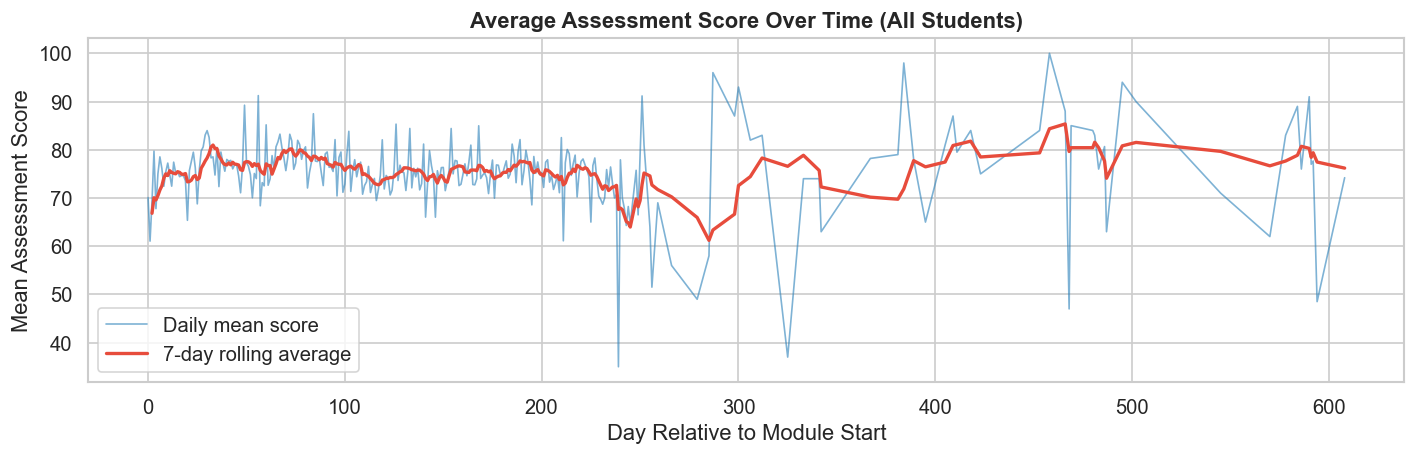

In [24]:
# ── Plot raw time series ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts_data.index, ts_data.values, color='#2980b9', lw=1, alpha=0.6, label='Daily mean score')

# 7-day rolling average for trend
rolling_7 = ts_data.rolling(window=7, min_periods=3).mean()
ax.plot(rolling_7.index, rolling_7.values, color='#e74c3c', lw=2, label='7-day rolling average')

ax.set_xlabel('Day Relative to Module Start')
ax.set_ylabel('Mean Assessment Score')
ax.set_title('Average Assessment Score Over Time (All Students)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/figures/ts_raw.png', bbox_inches='tight')
plt.show()

In [25]:
# ── Stationarity test (ADF) ───────────────────────────────────────────────────
# Resample to weekly to reduce noise and create regular intervals
ts_weekly = ts_data.groupby(ts_data.index // 7).mean()
ts_weekly.index = ts_weekly.index * 7  # convert back to days

adf_result = adfuller(ts_weekly.dropna())
print('Augmented Dickey-Fuller Test (H₀: series has unit root = non-stationary)')
print(f'  ADF Statistic : {adf_result[0]:.4f}')
print(f'  p-value       : {adf_result[1]:.4f}')
print(f'  Critical (5%) : {adf_result[4]["5%"]:.4f}')
if adf_result[1] < 0.05:
    print('  Result: Series is STATIONARY (p < 0.05) → d=0 for ARIMA')
else:
    print('  Result: Series is NON-STATIONARY → differencing required (d≥1)')

Augmented Dickey-Fuller Test (H₀: series has unit root = non-stationary)
  ADF Statistic : -6.5797
  p-value       : 0.0000
  Critical (5%) : -2.9044
  Result: Series is STATIONARY (p < 0.05) → d=0 for ARIMA


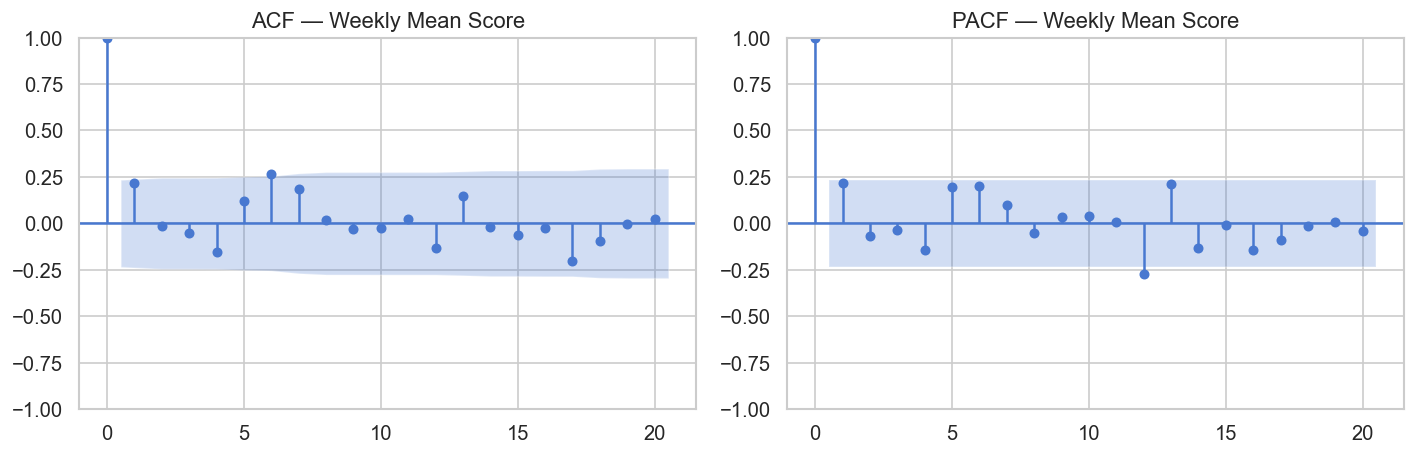

Use ACF to choose MA(q) order, PACF to choose AR(p) order.
Shaded region = 95% confidence band; lags outside = significant.


In [26]:
# ── ACF and PACF plots (for ARIMA order selection) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_weekly.dropna(), lags=20, ax=axes[0], title='ACF — Weekly Mean Score')
plot_pacf(ts_weekly.dropna(), lags=20, ax=axes[1], title='PACF — Weekly Mean Score', method='ywm')
plt.tight_layout()
plt.savefig('../../outputs/figures/ts_acf_pacf.png', bbox_inches='tight')
plt.show()
print('Use ACF to choose MA(q) order, PACF to choose AR(p) order.')
print('Shaded region = 95% confidence band; lags outside = significant.')

In [27]:
# ── Train/test split for time series (last 20% as holdout) ───────────────────
ts_clean = ts_weekly.dropna()
split_idx = int(len(ts_clean) * 0.8)
ts_train  = ts_clean.iloc[:split_idx]
ts_test   = ts_clean.iloc[split_idx:]
print(f'Train: {len(ts_train)} periods  |  Test (holdout): {len(ts_test)} periods')

Train: 56 periods  |  Test (holdout): 14 periods


In [28]:
# ── ARIMA Model ───────────────────────────────────────────────────────────────
# Order (p,d,q) selected from ACF/PACF above.
# Using (1,1,1) as a robust starting point for education score data.
# If ADF showed stationarity, use d=0.
d_order = 0 if adf_result[1] < 0.05 else 1
arima_order = (1, d_order, 1)

arima_model = ARIMA(ts_train, order=arima_order).fit()
print(arima_model.summary())

# Forecast on holdout
arima_forecast = arima_model.forecast(steps=len(ts_test))
arima_ci       = arima_model.get_forecast(steps=len(ts_test)).conf_int()

                               SARIMAX Results                                
Dep. Variable:                  score   No. Observations:                   56
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -199.986
Date:                Sat, 04 Apr 2026   AIC                            407.973
Time:                        08:42:41   BIC                            416.074
Sample:                             0   HQIC                           411.114
                                 - 56                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         74.5739      2.583     28.874      0.000      69.512      79.636
ar.L1          0.1687      0.574      0.294      0.769      -0.956       1.293
ma.L1          0.0967      0.576      0.168      0.8

In [29]:
# ── Holt-Winters Exponential Smoothing ────────────────────────────────────────
hw_model = ets.ExponentialSmoothing(
    ts_train,
    trend='add',
    initialization_method='estimated'
).fit()

hw_forecast = hw_model.forecast(steps=len(ts_test))
print(f'Holt-Winters alpha (smoothing level): {hw_model.params["smoothing_level"]:.4f}')
print(f'Holt-Winters beta  (trend): {hw_model.params["smoothing_trend"]:.4f}')

Holt-Winters alpha (smoothing level): 0.0000
Holt-Winters beta  (trend): 0.0000


In [30]:
# ── Time Series Model Evaluation ──────────────────────────────────────────────
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

def mape(actual, predicted):
    """Mean Absolute Percentage Error (handles zeros)."""
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

actual_vals = ts_test.values

arima_mape = mape(actual_vals, arima_forecast.values)
arima_rmse = np.sqrt(mean_squared_error(actual_vals, arima_forecast.values))

hw_mape = mape(actual_vals, hw_forecast.values)
hw_rmse = np.sqrt(mean_squared_error(actual_vals, hw_forecast.values))

ts_eval = pd.DataFrame({
    'Model'    : ['ARIMA', 'Holt-Winters'],
    'MAPE (%)'  : [round(arima_mape, 2), round(hw_mape, 2)],
    'RMSE'     : [round(arima_rmse, 4), round(hw_rmse, 4)],
    'Acceptable': ['MAPE < 15%', 'MAPE < 15%']
})
print('Time Series Model Evaluation:')
print(ts_eval.to_string(index=False))
ts_eval.to_csv('../../outputs/tables/timeseries_evaluation.csv', index=False)

Time Series Model Evaluation:
       Model  MAPE (%)    RMSE Acceptable
       ARIMA     11.20 11.6490 MAPE < 15%
Holt-Winters     11.65 12.4302 MAPE < 15%


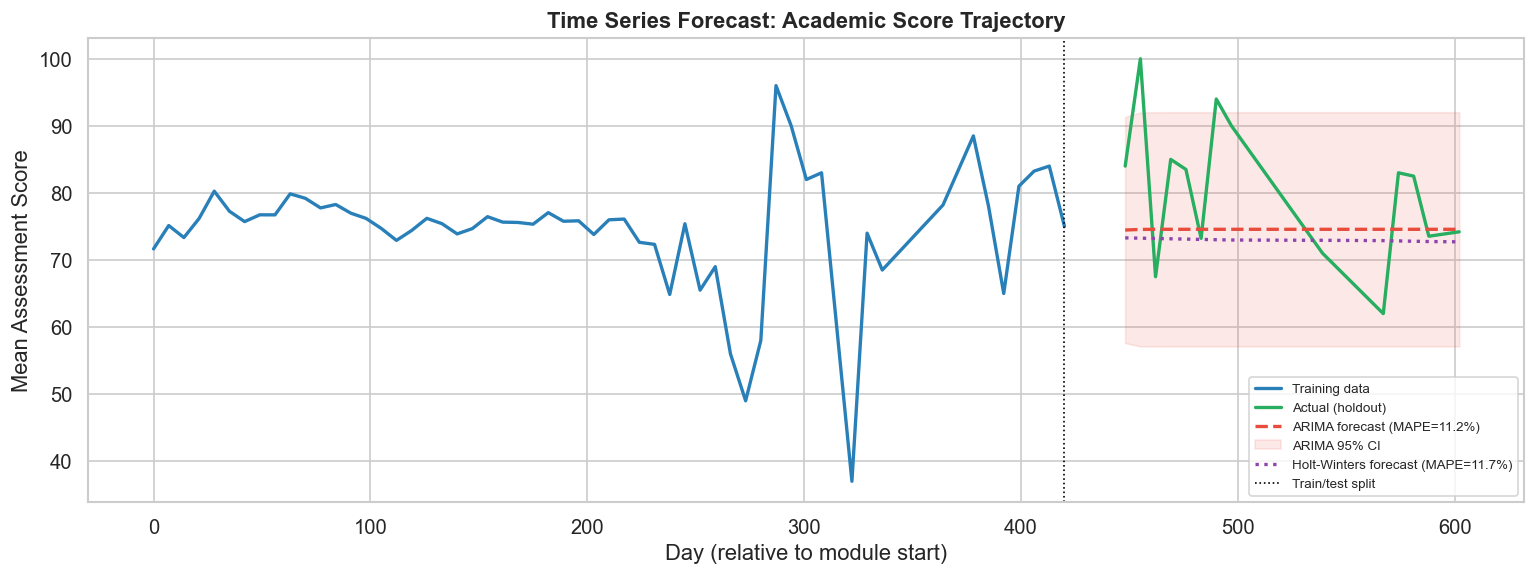

In [31]:
# ── Time Series Forecast Plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(ts_train.index, ts_train.values, color='#2980b9', lw=2, label='Training data')
ax.plot(ts_test.index,  ts_test.values,  color='#27ae60', lw=2, label='Actual (holdout)')

# ARIMA forecast
ax.plot(ts_test.index, arima_forecast.values, color='#e74c3c',
        linestyle='--', lw=2, label=f'ARIMA forecast (MAPE={arima_mape:.1f}%)')
ax.fill_between(ts_test.index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1],
                color='#e74c3c', alpha=0.12, label='ARIMA 95% CI')

# Holt-Winters forecast
ax.plot(ts_test.index, hw_forecast.values, color='#8e44ad',
        linestyle=':', lw=2, label=f'Holt-Winters forecast (MAPE={hw_mape:.1f}%)')

ax.axvline(ts_train.index[-1], color='black', linestyle=':', lw=1, label='Train/test split')
ax.set_xlabel('Day (relative to module start)')
ax.set_ylabel('Mean Assessment Score')
ax.set_title('Time Series Forecast: Academic Score Trajectory', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('../../outputs/figures/ts_forecast.png', bbox_inches='tight')
plt.show()

---
## Results Summary & Interpretation

In [33]:
print('=' * 65)
print(' PREDICTIVE ANALYSIS — RESULTS SUMMARY')
print('=' * 65)

print('\n[T3.2] OLS Regression (Predicting avg_score_TMA)')
print(f'  R²              = {ols_model.rsquared:.4f}')
print(f'  Adjusted R²     = {ols_model.rsquared_adj:.4f}')
print(f'  F-stat p-value  = {ols_model.f_pvalue:.4e}')
print(f'  Interpretation  : Model explains {ols_model.rsquared*100:.1f}% of variance in TMA scores.')

print('\n[T3.3 & T3.4] Logistic Regression (Predicting success_binary)')
print(f'  Test Accuracy   = {acc:.4f}')
print(f'  AUC-ROC         = {auc:.4f}  (threshold: > 0.70)')
print(f'  CV AUC (5-fold) = {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
interpretation = 'successfully' if auc > 0.7 else 'does not yet'
direction = '>' if auc > 0.7 else '<'
print(f'  Interpretation  : Model {interpretation} discriminates'
      f' between successful and unsuccessful students (AUC {direction} 0.70).')

print('\n[T3.5 & T3.6] Time Series Modelling')
print(f'  ARIMA MAPE      = {arima_mape:.2f}%  (acceptable < 15%)')
print(f'  Holt-Winters MAPE = {hw_mape:.2f}%')

print('\n[Hypothesis Support]')
top_features = or_df.sort_values('Odds_Ratio', ascending=False)
top_sig = top_features[top_features['Significant (p<0.05)']].head(3)
for feat, row in top_sig.iterrows():
    print(f'  {feat:25s} → OR = {row["Odds_Ratio"]:.3f} (significant)')
print('\n  Positive OR > 1 for engagement features supports H₁:')
print('  Positive learning experiences increase probability of academic success.')
print('=' * 65)

 PREDICTIVE ANALYSIS — RESULTS SUMMARY

[T3.2] OLS Regression (Predicting avg_score_TMA)
  R²              = 0.0934
  Adjusted R²     = 0.0932
  F-stat p-value  = 0.0000e+00
  Interpretation  : Model explains 9.3% of variance in TMA scores.

[T3.3 & T3.4] Logistic Regression (Predicting success_binary)
  Test Accuracy   = 0.8275
  AUC-ROC         = 0.9050  (threshold: > 0.70)
  CV AUC (5-fold) = 0.8986 ± 0.0048
  Interpretation  : Model successfully discriminates between successful and unsuccessful students (AUC > 0.70).

[T3.5 & T3.6] Time Series Modelling
  ARIMA MAPE      = 11.20%  (acceptable < 15%)
  Holt-Winters MAPE = 11.65%

[Hypothesis Support]
  avg_score_TMA             → OR = 1.047 (significant)
  submission_delay          → OR = 1.008 (significant)
  total_clicks              → OR = 1.003 (significant)

  Positive OR > 1 for engagement features supports H₁:
  Positive learning experiences increase probability of academic success.
